In [4]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import pandas as pd
from tqdm import tqdm
import warnings
import json
warnings.filterwarnings('ignore')

from eval import evaluate_object_detector
from style import combined_plot 


class resultHandler():
    def __init__(self, folder_path):
        self.folder_path = folder_path
        self.SAT = folder_path.parent.name
        self.MODE = folder_path.name
        self.identifiers = [x.stem.split('perfect_')[-1] for x in self.folder_path.iterdir()]
    
    def find_coco_metrics_files(self):
        cocometrics = list(self.folder_path.glob('**/**/coco_metrics.json'))
        return cocometrics
    
    def parse_json_test(self, json_file_path):
        # implementation of parse_json_test function
        partial = {
            'Seed': Path(json_file_path).parent.parent.name.split('_')[0],
            'BS': Path(json_file_path).parent.parent.name.split('_')[2],
            'LR': Path(json_file_path).parent.parent.name.split('_')[4],
            'ME': Path(json_file_path).parent.parent.name.split('_')[6],
            'OPT': Path(json_file_path).parent.parent.name.split('_')[8],
            'Band': Path(json_file_path).parent.parent.parent.name.split('perfect_')[-1],
        }

        # Read the JSON file
        with open(json_file_path, 'r') as f:
            data = json.load(f)


        # merge data and partial 
        data = {**data, **partial}
        return data
    
    def find_best_config(self, all_band):
        # Group by the desired columns and compute the mean
        grouped_bs = all_band.groupby(['Band', 'BS', 'LR', 'ME']).mean()
        
        # Count the number of occurrences (rows) for each configuration
        count_bs = all_band.groupby(['Band', 'BS', 'LR', 'ME']).size()
        
        # Filter out configurations with fewer than 2 rows
        valid_configs = count_bs[count_bs >= 2].index
        
        # Create a filtered grouped_bs DataFrame with only valid configurations
        filtered_grouped_bs = grouped_bs.loc[valid_configs]
        
        bestConfig = {idx: None for idx in self.identifiers}  # Initialize with None by default
        for idx, bandSel in enumerate(self.identifiers):
            # Filter only the rows corresponding to the current band
            band_specific_configs = filtered_grouped_bs[filtered_grouped_bs.index.get_level_values('Band') == bandSel]
            
            if not band_specific_configs.empty:  # Check if there are valid configurations for the band
                # Find the best configuration by maximizing 'coco/bbox_mAP_50'
                BS, LR, ME = band_specific_configs['coco/bbox_mAP_50'].idxmax()[1:]
                BS, LR, ME = int(BS), float(LR), int(ME)
                bestConfig[bandSel] = (BS, LR, ME)
            else:
                # No valid configuration found for this band, remains None
                bestConfig[bandSel] = None
        self.bestConfig = bestConfig
        return bestConfig
    
    def filter_results(self, all_band, bestConfig):
        print("Filtering results...")
        print("Best configurations:")
        print(bestConfig)
        all_band_best = pd.DataFrame()
        for Band in self.identifiers:
            if bestConfig[Band] is None:
                continue
            BS, LR, ME = bestConfig[Band]
            filtered_all_band = all_band[
                (all_band['Band'] == Band) &
                (all_band['BS'] == str(BS)) &
                (all_band['LR'] == str(LR)) &
                (all_band['ME'] == str(ME))]
            all_band_best = pd.concat([all_band_best, filtered_all_band])
        return all_band_best.dropna()
    
    @staticmethod
    def filter_cols(df):
        return df[['coco/bbox_mAP_50', 'coco/bbox_mAP_75', 'coco/bbox_mAP']]    

    @staticmethod
    def get_first_band(band):
        # Estrai il numero dalla stringa 'b'
        y = band.split('b')[-1]
        if len(y) > 2:
            return int(y.split('_')[0])
        else:
            return int(y)
    
    def sorting(self, all_band_best):
        return all_band_best.sort_values(by='Band', key=lambda x: x.map(self.get_first_band), ascending=True)
    
    
    def process_results(self, grouped=False):
        cocometrics = self.find_coco_metrics_files()
        all_band = pd.DataFrame([self.parse_json_test(x) for x in cocometrics])
        all_band.reset_index(inplace=True)
        all_band.dropna(inplace=True) # removing NaN results
        self.ALL = all_band
        bestConfig = self.find_best_config(all_band)
        all_band_best = self.filter_results(all_band, bestConfig)
        self.all_band_best = all_band_best
        
        if grouped:
            return self.sorting(self.filter_cols(all_band_best.groupby(['Band', 'BS', 'LR', 'ME']).mean()))
        else:
            return all_band_best
        
        
    def pr_curve(self):
        pr_x_band = {i:[] for i in all_band_best.reset_index()['Band'].unique()}

        grouped_bs = self.all_band_best.groupby(['Band', 'BS', 'LR', 'ME']).mean() # average over seeds
        for idx, row in tqdm(grouped_bs.iterrows()):
            Band, BS, LR, ME = idx
            print(f"Band: {Band}, BS: {BS}, LR: {LR}, ME: {ME}")
            firstBand = self.get_first_band(Band) # bc we use the first band as labels
            
            ann_file = { 'VENuS': f'/Data_large/marine/Datasets/VENuS/annotations/perfect/test__band_{firstBand}.json', 
                        'Sentinel': f'/Data_large/marine/Datasets/VDS2Raw/annotations/test__band_{firstBand}.json'}[self.SAT]
                
            # get folder:
            band_path = f'/Data_large/marine/PythonProjects/MMDET/checkpoints/{self.SAT}/{self.MODE}/perfect_{Band}'
            folders = list(Path(f'{band_path}').iterdir())  
            # filter folders with the BS, LR, ME values
            folders = [f for f in folders if (f'BS_{BS}' in f.name) and (f'LR_{LR}' in f.name) and (f'ME_{ME}' in f.name)]
            
            print(f"Found {len(folders)} folders")
            for folder in tqdm(folders):
                res_file = list(folder.glob('**/*.json'))
                res_file = [x for x in res_file if 'test_results.bbox' in str(x)]
                try:
                    assert len(res_file) == 1, f"Found {len(res_file)} json files. Expected 1. \n {res_file}"
                except AssertionError:
                    print(f"Error in {res_file}")
                    continue
                res_file = res_file[0].as_posix()
                print(f"Res file: {res_file}")
                try:
                    stats, eval_results, cocoeval_tmp = evaluate_object_detector(res_file, ann_file)
                    pr_x_band[Band].append(cocoeval_tmp)
                except IndexError:
                    print(f"Error in {res_file}")
                    continue
                
        return pr_x_band
                
        
        
# Create an instance of the resultHandler class
mode = 'Multi' # 'Single' or 'Multi'
Sat = 'Sentinel' # 'VENuS' or 'Sentinel'
handler = resultHandler(Path(f'/Data_large/marine/PythonProjects/MMDET/checkpoints/{Sat}/{mode}'))

# Process the results
all_band_best = handler.process_results(grouped=False)
all_band = handler.ALL
pr_x_band = handler.pr_curve()

# Save:
all_band_best.to_csv(f'{Sat}/{mode}_all_best.csv')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Filtering results...
Best configurations:
{'b2_b3_b4': (4, 0.001, 130), 'b2_b4': (2, 0.0005, 130), 'b2_b3_b8': (4, 0.001, 130), 'b2_b3': (2, 0.001, 130), 'b2_b4_b8': (1, 0.001, 130)}


0it [00:00, ?it/s]

Band: b2_b3, BS: 2, LR: 0.001, ME: 130
Found 5 folders


Res file: /Data_large/marine/PythonProjects/MMDET/checkpoints/Sentinel/Multi/perfect_b2_b3/71_BS_2_LR_0.001_ME_130_OPT_SGD/test_results.bbox.json
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.03s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.10s).
Accumulating evaluation results...
DONE (t=0.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.082
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.340
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.011
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.073
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.322
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.08

...

100%|██████████| 5/5 [00:00<00:00,  8.77it/s]
4it [00:02,  1.95it/s]

DONE (t=0.08s).
Accumulating evaluation results...
DONE (t=0.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.031
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.121
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.006
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.025
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.260
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.041
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.092
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.111
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.102
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.300
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= la

Res file: /Data_large/marine/PythonProjects/MMDET/checkpoints/Sentinel/Multi/perfect_b2_b4_b8/42_BS_1_LR_0.001_ME_130_OPT_SGD/test_results.bbox.json
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*


100%|██████████| 2/2 [00:00<00:00, 13.50it/s]
5it [00:02,  2.15it/s]

DONE (t=0.06s).
Accumulating evaluation results...
DONE (t=0.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.133
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.483
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.008
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.128
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.306
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.086
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.199
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.222
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.212
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.425
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= la

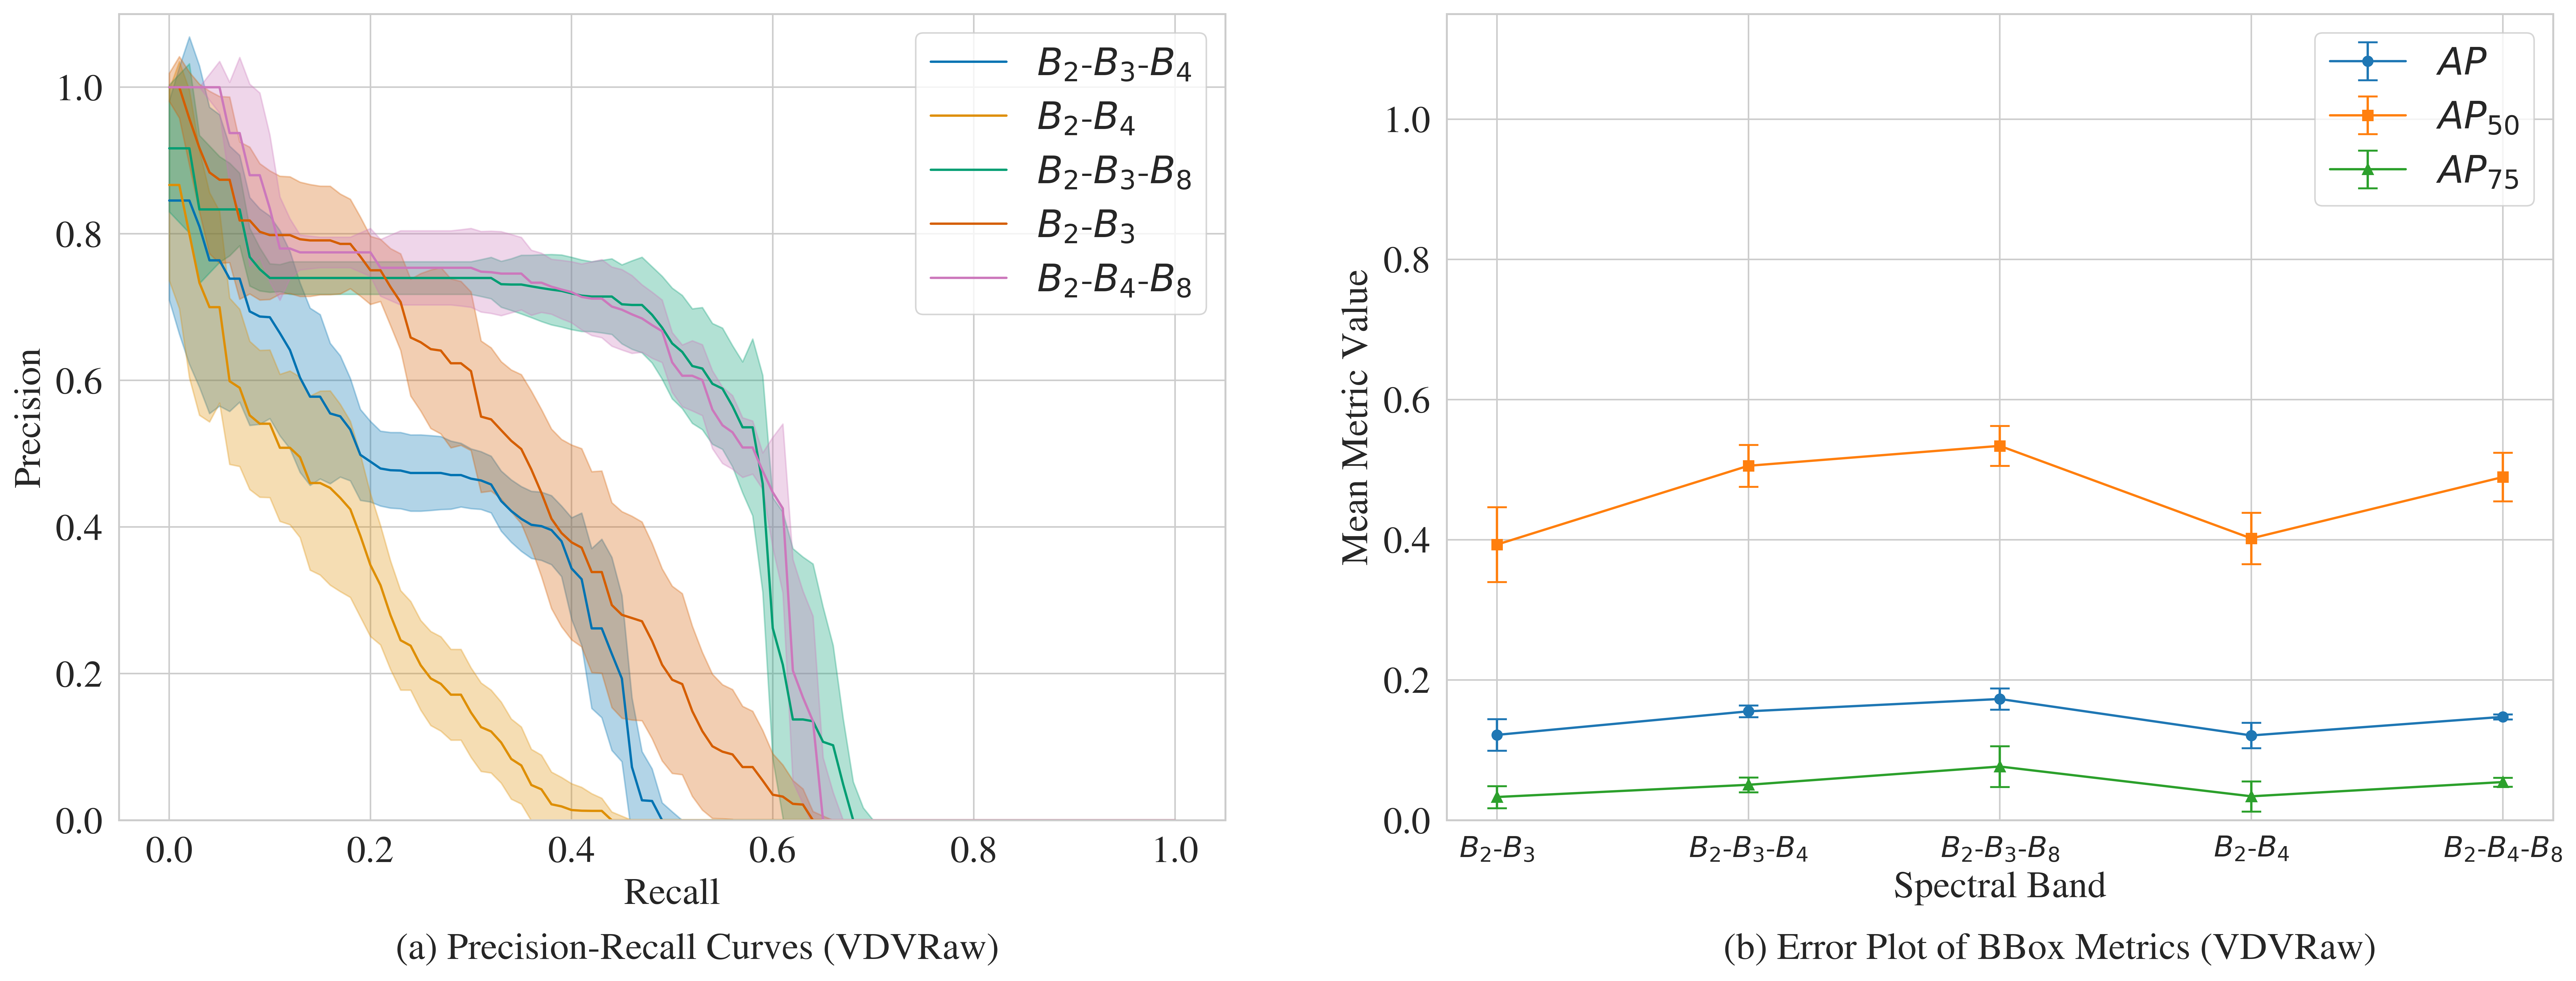

,Band,mean_mAP,std_mAP,mean_mAP_50,std_mAP_50,mean_mAP_75,std_mAP_75
0,b2_b3,0.1218,0.022565,0.3932,0.053354,0.033200,0.015707
1,b2_b3_b4,0.1554,0.008325,0.5056,0.029695,0.050600,0.010526
2,b2_b3_b8,0.1730,0.015000,0.5340,0.028583,0.076667,0.029143
3,b2_b4,0.1210,0.018138,0.4020,0.036790,0.034200,0.021510
4,b2_b4_b8,0.1475,0.003536,0.4895,0.034648,0.054500,0.006364


In [5]:
combined_plot(pr_x_band, all_band_best, savepath=f'{Sat}/{mode}_PR_curve.png')